In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import joblib
import shap
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, roc_curve, auc


In [21]:
# Read csv files
df= pd.read_csv("fourth_feature_df_31_12_2025.csv")
df.head(10)


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,GCS_max,GCS_mean,Lactate_min,Lactate_max,Lactate_mean,BUN_min,BUN_mean,...,HR_MEAN,HR_MAX,HR_STD,RDW_max,RDW_mean,RDW_min,RDW_std,age_adj_comorbidity_score,MEANBP_MIN,MEANBP_MEAN
0,3,145834,211552,6.0,4.444444,1.3,8.8,3.800000,36.0,40.500000,...,98.925373,168.0,28.103334,15.7,15.400000,15.0,0.273861,16.0,40.000000,76.728071
1,6,107064,228232,6.0,6.000000,NaN,NaN,NaN,65.0,65.500000,...,84.791667,100.0,5.573334,17.0,16.450000,15.9,0.777817,12.0,72.666702,87.175435
2,9,150750,220597,5.0,2.600000,1.9,2.7,2.380000,17.0,18.500000,...,87.644737,111.0,8.162849,14.3,14.000000,13.8,0.264575,12.0,67.000000,98.289474
3,12,112213,232669,6.0,4.842105,1.6,15.1,8.716667,28.0,35.500000,...,83.208333,105.0,8.518311,14.9,14.625000,14.2,0.309570,7.0,73.000000,96.819444
4,17,194023,277042,6.0,5.615385,0.9,0.9,0.900000,10.0,10.666667,...,82.400000,114.0,11.049719,12.9,12.766667,12.6,0.152753,0.0,53.000000,69.714286
5,21,109451,217847,6.0,6.000000,1.5,2.3,2.060000,50.0,77.666667,...,71.690909,125.0,17.346013,18.2,17.700000,17.4,0.435890,21.0,59.000000,76.964286
6,21,111970,216859,6.0,5.923077,1.6,2.7,2.150000,50.0,56.500000,...,77.580645,100.0,7.898015,17.7,17.200000,16.7,0.707107,20.0,43.000000,60.703703
7,25,129635,203487,6.0,6.000000,1.0,1.8,1.400000,34.0,46.333333,...,76.898305,104.0,10.540063,13.1,13.000000,12.9,0.081650,1.0,24.000000,66.290913
8,26,197661,244882,6.0,6.000000,NaN,NaN,NaN,28.0,29.500000,...,70.404255,86.0,7.859250,13.7,13.500000,13.3,0.282843,15.0,51.666698,61.121216
9,31,128652,254478,4.0,2.920000,1.4,1.5,1.450000,11.0,12.000000,...,50.948718,57.0,2.790479,15.2,14.950000,14.7,0.353553,18.0,57.333302,72.751940


In [22]:
# Find dataset size and column data types
print(df.shape)
pd.DataFrame({"column": df.columns, "dtype": df.dtypes.values})



(21247, 40)


,column,dtype
0,SUBJECT_ID,int64
1,HADM_ID,int64
2,ICUSTAY_ID,int64
3,GCS_max,float64
4,GCS_mean,float64
5,Lactate_min,float64
6,Lactate_max,float64
7,Lactate_mean,float64
8,BUN_min,float64
9,BUN_mean,float64


In [23]:
# Checking missing values
df.isnull().sum()

SUBJECT_ID                       0
HADM_ID                          0
ICUSTAY_ID                       0
GCS_max                        309
GCS_mean                       309
Lactate_min                   9354
Lactate_max                   9354
Lactate_mean                  9354
BUN_min                        171
BUN_mean                       171
Bilirubin_max                11925
Bilirubin_mean               11925
MORTALITY_INHOSPITAL             0
MORTALITY_90DAY                  0
MORTALITY_180DAY                 0
AG_MEAN                        282
AG_MAX                         282
AG_MIN                         282
AG_STD                        1162
SYSBP_MIN                      311
SYSBP_MEAN                     311
SYSBP_STD                      314
DIASBP_MIN                     312
DIASBP_MEAN                    312
AGE                              0
RR_MEAN                        317
RR_MAX                         317
RR_MIN                         317
TEMP_STD            

In [24]:
# Checking missing value and value counts of Target varaible
print(df['MORTALITY_180DAY'].isnull().sum())
df['MORTALITY_180DAY'].value_counts()


0


MORTALITY_180DAY
0    15625
1     5622
Name: count, dtype: int64

In [25]:
# Print the all columns names
print(df.columns.tolist())

['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'GCS_max', 'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min', 'BUN_mean', 'Bilirubin_max', 'Bilirubin_mean', 'MORTALITY_INHOSPITAL', 'MORTALITY_90DAY', 'MORTALITY_180DAY', 'AG_MEAN', 'AG_MAX', 'AG_MIN', 'AG_STD', 'SYSBP_MIN', 'SYSBP_MEAN', 'SYSBP_STD', 'DIASBP_MIN', 'DIASBP_MEAN', 'AGE', 'RR_MEAN', 'RR_MAX', 'RR_MIN', 'TEMP_STD', 'TEMP_MIN', 'HR_MEAN', 'HR_MAX', 'HR_STD', 'RDW_max', 'RDW_mean', 'RDW_min', 'RDW_std', 'age_adj_comorbidity_score', 'MEANBP_MIN', 'MEANBP_MEAN']


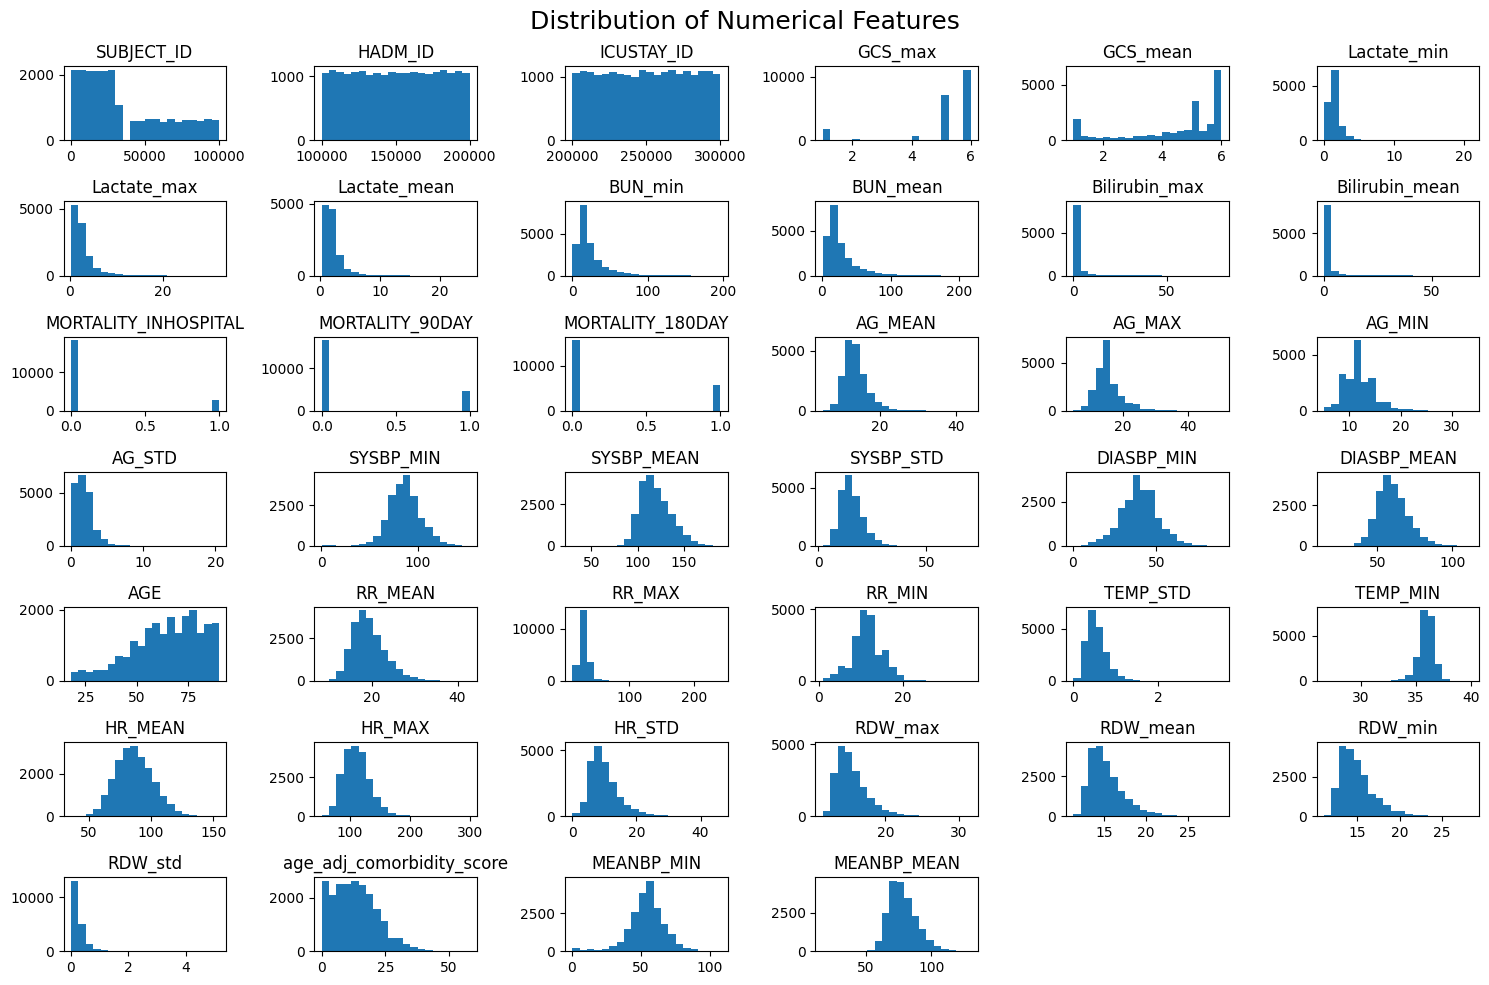

In [26]:
# Univariate Analysis 
df.hist(bins=20, figsize=(15, 10), grid=False)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

In [27]:
# Calculate correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

                           SUBJECT_ID   HADM_ID  ICUSTAY_ID   GCS_max  \
SUBJECT_ID                   1.000000  0.017256    0.001414 -0.480616   
HADM_ID                      0.017256  1.000000   -0.002542 -0.005877   
ICUSTAY_ID                   0.001414 -0.002542    1.000000 -0.012395   
GCS_max                     -0.480616 -0.005877   -0.012395  1.000000   
GCS_mean                    -0.483903 -0.006598   -0.012657  0.838020   
Lactate_min                 -0.093953 -0.017834    0.004259  0.019551   
Lactate_max                 -0.055512 -0.005262    0.024530 -0.094879   
Lactate_mean                -0.074950 -0.010154    0.018651 -0.055479   
BUN_min                     -0.036331 -0.010151    0.004512 -0.016643   
BUN_mean                    -0.034047 -0.009534    0.003956 -0.023297   
Bilirubin_max               -0.002809 -0.006714   -0.004451  0.017498   
Bilirubin_mean              -0.004024 -0.006065   -0.003351  0.020860   
MORTALITY_INHOSPITAL        -0.019946 -0.010906    

In [28]:
# Split data
X = df.drop(['MORTALITY_INHOSPITAL','MORTALITY_90DAY', 'MORTALITY_180DAY', 'SUBJECT_ID','HADM_ID','ICUSTAY_ID'], axis=1)
y = df['MORTALITY_180DAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Filled the missing values with x_train median to avoid data leakage
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)




Train size: 16997
Test size: 4250


In [29]:
# Train the different model

model_lr= LogisticRegression(class_weight="balanced", max_iter=2000)
model_lr.fit(X_train, y_train)

model_dtc=DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, class_weight="balanced", random_state=42)
model_dtc.fit(X_train, y_train)

model_rfc= RandomForestClassifier(n_estimators=400,random_state=42,n_jobs=-1,class_weight="balanced_subsample")
model_rfc.fit(X_train, y_train)


def calculation(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    auroc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    cf_matrix = confusion_matrix(y_test, y_pred)
    cl_report = classification_report(y_test, y_pred, digits=4)
    return auroc, ap, cf_matrix, cl_report

# Calculate metrics for all models
print("Logistic Regression:")
auroc, ap, cf_matrix, cl_report = calculation(model_lr, X_test, y_test)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)

print("DecisionTreeClassifier:")
auroc, ap, cf_matrix, cl_report = calculation(model_dtc, X_test, y_test)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)

print("Random Forest:")
auroc, ap, cf_matrix, cl_report = calculation(model_rfc, X_test, y_test)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)




c:\Users\ahwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
Area Under the Receiver Operating Characteristic curve:0.7996117333333334, Average Precision:0.5992318297813499
Confusion Matrix:
[[2276  849]
 [ 337  788]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8710    0.7283    0.7933      3125
           1     0.4814    0.7004    0.5706      1125

    accuracy                         0.7209      4250
   macro avg     0.6762    0.7144    0.6820      4250
weighted avg     0.7679    0.7209    0.7344      4250

DecisionTreeClassifier:
Area Under the Receiver Operating Characteristic curve:0.7591991466666667, Average Precision:0.49617108978461155
Confusion Matrix:
[[2199  926]
 [ 361  764]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8590    0.7037    0.7736      3125
           1     0.4521    0.6791    0.5428      1125

    accuracy                         0.6972      4250
   macro avg     0.6555    0.6914    0.6582      

In [30]:
# XGBoost model

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb=xgb.XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric=["auc", "aucpr"],
        random_state=42,
        n_jobs=-1)

model_xgb.fit(X_train, y_train)

print("XGBoost Classifier:")
auroc, ap, cf_matrix, cl_report = calculation(model_xgb, X_test, y_test)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)



XGBoost Classifier:
Area Under the Receiver Operating Characteristic curve:0.8253454222222222, Average Precision:0.640195614850465
Confusion Matrix:
[[2464  661]
 [ 351  774]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8753    0.7885    0.8296      3125
           1     0.5394    0.6880    0.6047      1125

    accuracy                         0.7619      4250
   macro avg     0.7073    0.7382    0.7172      4250
weighted avg     0.7864    0.7619    0.7701      4250



In [31]:
# With KFold cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"auroc": "roc_auc", "ap": "average_precision"}

def run_cv(name, model):
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    auroc_mean = res['test_auroc'].mean()
    auroc_std  = res['test_auroc'].std()
    ap_mean    = res['test_ap'].mean()
    ap_std     = res['test_ap'].std()

    print(f"{name} (5-Fold CV)")
    print(f"AUROC: {auroc_mean:.4f} ± {auroc_std:.4f}")
    print(f"AP: {ap_mean:.4f} ± {ap_std:.4f}\n")

    return {"model": name,"auroc_mean": auroc_mean, "auroc_std": auroc_std,"ap_mean": ap_mean, "ap_std": ap_std}

# Logistic Regression 
lr_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_lr)])

# Decision Tree
dtc_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_dtc)])

# Random Forest
rfc_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_rfc)])

# XGBoost model
xgb_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_xgb)])

# Collecting results
results = []

results.append(run_cv("Logistic Regression", lr_pipe))
results.append(run_cv("Decision Tree", dtc_pipe))
results.append(run_cv("Random Forest", rfc_pipe))
results.append(run_cv("XGBoost", xgb_pipe))
print(results)

Logistic Regression (5-Fold CV)
AUROC: 0.8001 ± 0.0058
AP: 0.5960 ± 0.0148

Decision Tree (5-Fold CV)
AUROC: 0.7513 ± 0.0046
AP: 0.4826 ± 0.0053

Random Forest (5-Fold CV)
AUROC: 0.8062 ± 0.0028
AP: 0.5898 ± 0.0103

XGBoost (5-Fold CV)
AUROC: 0.8114 ± 0.0075
AP: 0.6132 ± 0.0109

[{'model': 'Logistic Regression', 'auroc_mean': np.float64(0.8000688519095291), 'auroc_std': np.float64(0.005794704943366199), 'ap_mean': np.float64(0.5959545579358101), 'ap_std': np.float64(0.014791117757009286)}, {'model': 'Decision Tree', 'auroc_mean': np.float64(0.7513276534420962), 'auroc_std': np.float64(0.004560426732612994), 'ap_mean': np.float64(0.48263114121340694), 'ap_std': np.float64(0.005257985522633393)}, {'model': 'Random Forest', 'auroc_mean': np.float64(0.8062324883450749), 'auroc_std': np.float64(0.002751042249186929), 'ap_mean': np.float64(0.5898266689690403), 'ap_std': np.float64(0.01032454214431637)}, {'model': 'XGBoost', 'auroc_mean': np.float64(0.8114130088246199), 'auroc_std': np.float6

In [32]:
# Create dataframe of result
results_df = pd.DataFrame(results)

results_df

,model,auroc_mean,auroc_std,ap_mean,ap_std
0,Logistic Regression,0.800069,0.005795,0.595955,0.014791
1,Decision Tree,0.751328,0.004560,0.482631,0.005258
2,Random Forest,0.806232,0.002751,0.589827,0.010325
3,XGBoost,0.811413,0.007465,0.613172,0.010901


In [33]:
# Finding the best model
best_model = results_df.sort_values(by=["ap_mean", "auroc_mean"],ascending=False).iloc[0]

print("Selected model:", best_model["model"])

# pick the best pipeline object (not only name)
models = {
    "Logistic Regression": lr_pipe,
    "Decision Tree": dtc_pipe,
    "Random Forest": rfc_pipe,
    "XGBoost": xgb_pipe,
}

best_name = best_model["model"]
final_model = clone(models[best_name]) 
final_model.fit(X_train, y_train)       





Selected model: XGBoost


,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,objective,'binary:logistic'


In [34]:
# Evaluate on held-out test set
auroc, ap, cf_matrix, cl_report = calculation(final_model, X_test, y_test)
print(f"Final model (test) AUROC: {auroc:.4f}, AP: {ap:.4f}")
print("Confusion Matrix:")
print(cf_matrix)
print("Classification Report:")
print(cl_report)

Final model (test) AUROC: 0.8253, AP: 0.6402
Confusion Matrix:
[[2464  661]
 [ 351  774]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8753    0.7885    0.8296      3125
           1     0.5394    0.6880    0.6047      1125

    accuracy                         0.7619      4250
   macro avg     0.7073    0.7382    0.7172      4250
weighted avg     0.7864    0.7619    0.7701      4250



                      feature  importance
31  age_adj_comorbidity_score    0.119552
0                     GCS_max    0.084349
29                    RDW_min    0.054788
5                     BUN_min    0.050394
18                        AGE    0.044659
28                   RDW_mean    0.036886
1                    GCS_mean    0.030828
19                    RR_MEAN    0.028775
9                     AG_MEAN    0.028269
10                     AG_MAX    0.028233
8              Bilirubin_mean    0.026433
14                 SYSBP_MEAN    0.024222
2                 Lactate_min    0.023044
27                    RDW_max    0.022959
23                   TEMP_MIN    0.022897
21                     RR_MIN    0.022325
7               Bilirubin_max    0.020889
24                    HR_MEAN    0.020796
3                 Lactate_max    0.020578
4                Lactate_mean    0.020458
11                     AG_MIN    0.020433
15                  SYSBP_STD    0.020430
33                MEANBP_MEAN    0

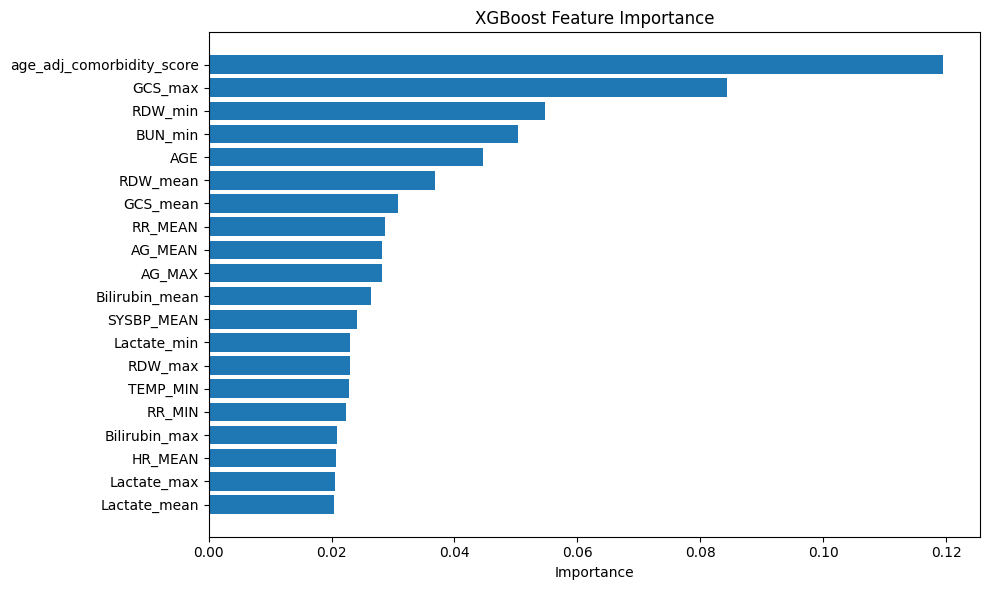

In [35]:
#Feature importance of XGBoost
xgb_fitted = final_model.named_steps["model"]

importance = xgb_fitted.feature_importances_

fi_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(fi_xgb)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(fi_xgb["feature"].head(20)[::-1],
         fi_xgb["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


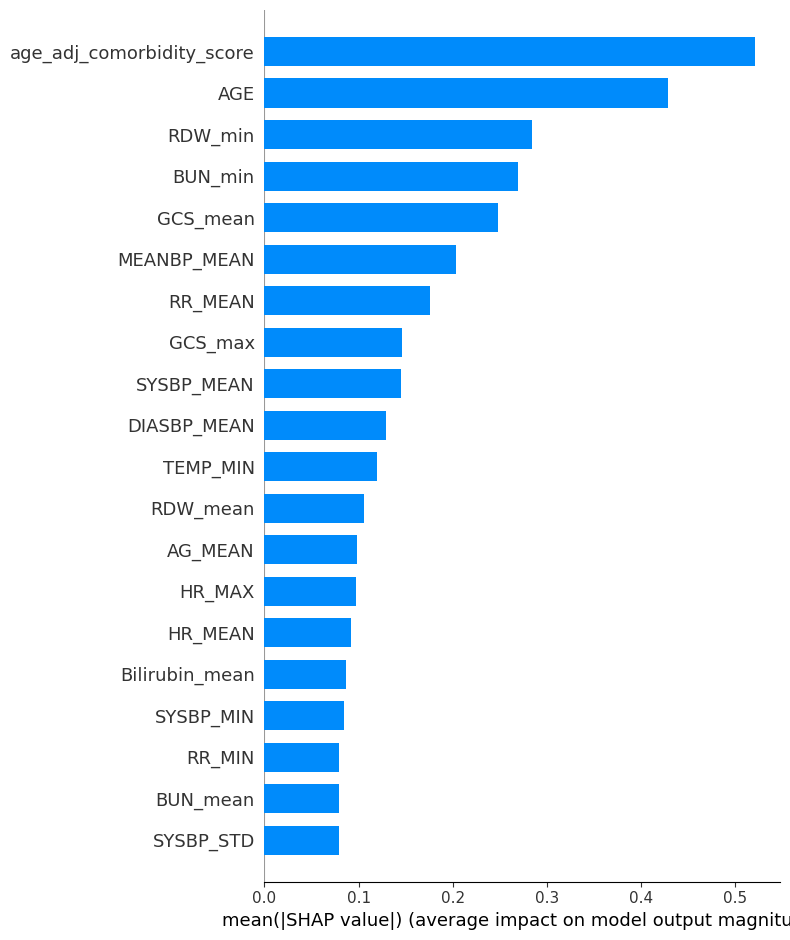

In [36]:
# SHAP summary plot showing global feature importance for the final XGBoost model
explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")


In [37]:
#joblib file of final model

joblib.dump(final_model, "XGBoost_mortality_180days.joblib")


#pkl file of final model
# with open('XGBoost_third_feature.pkl', 'wb') as File:
#     pickle.dump(final_model, File)

['XGBoost_mortality_180days.joblib']